In [1]:
import os
import pandas as pd
from glob import glob
import numpy as np
from matplotlib import pyplot as plt
import re
from itertools import combinations
import xml.etree.ElementTree as ET
import tiffile as tf
from matplotlib import colors
from scipy.ndimage import shift
from scipy.ndimage import gaussian_filter
from scipy.ndimage import label
from scipy.special import softmax
from skimage.registration import phase_cross_correlation
from skimage import io
from skimage import measure
import cellpose
import suite2p

def stitch_images(images, percent_overlap):
    image1 = images[0]
    image2 = images[1]
    image3 = images[2]
    image4 = images[3]
    # image format numPlanes x nX x nY
    # all four images must have same shape
    # 1 2
    # 4 3
    stitched_images = []
    for plane in range(image1.shape[0]):
        #print(plane)
        num_cut = np.round(image1.shape[1]*percent_overlap/2).astype(int)
        i1 = image1[plane, :(-num_cut), :(-num_cut)]
        i2 = image2[plane, :(-num_cut), num_cut:]
        i3 = image3[plane, num_cut:, num_cut:]
        i4 = image4[plane, :(-num_cut), :(-num_cut)]
        row1 = np.concatenate((i1, i2), axis=1)
        row2 = np.concatenate((i4, i3), axis=1)
        stitched_images.append(np.concatenate((row1, row2), axis=0))
    
    stitched_image = np.full((len(stitched_images), stitched_images[0].shape[0], stitched_images[0].shape[1]), np.nan)
    for plane in range(len(stitched_images)):
        stitched_image[plane, :, :] = stitched_images[plane]

    return stitched_image

In [2]:
i1BR = io.imread('/Volumes/2P3_data/Sam/unmixing_coefficients/spatial control mouse #1 20250722/BR2EmFilt_1080nm_230poc_600pmt_pos1-086/BR2EmFilt_1080nm_230poc_600pmt_pos1-086_Cycle00001_Ch1_000001.ome.tif')
i2BR = io.imread('/Volumes/2P3_data/Sam/unmixing_coefficients/spatial control mouse #1 20250722/BR2EmFilt_1080nm_230poc_600pmt_pos2-087/BR2EmFilt_1080nm_230poc_600pmt_pos2-087_Cycle00001_Ch1_000001.ome.tif')
i3BR = io.imread('/Volumes/2P3_data/Sam/unmixing_coefficients/spatial control mouse #1 20250722/BR2EmFilt_1080nm_230poc_600pmt_pos3-088/BR2EmFilt_1080nm_230poc_600pmt_pos3-088_Cycle00001_Ch1_000001.ome.tif')
i4BR = io.imread('/Volumes/2P3_data/Sam/unmixing_coefficients/spatial control mouse #1 20250722/BR2EmFilt_1080nm_230poc_600pmt_pos4-089/BR2EmFilt_1080nm_230poc_600pmt_pos4-089_Cycle00001_Ch1_000001.ome.tif')

# change file names
i1FR = io.imread('/Volumes/2P3_data/Sam/unmixing_coefficients/spatial control mouse #1 20250722/FarRedEmFilt_1240nm_493poc_700pmt_pos1-098/FarRedEmFilt_1240nm_493poc_700pmt_pos1-098_Cycle00001_Ch1_000001.ome.tif')
i2FR = io.imread('/Volumes/2P3_data/Sam/unmixing_coefficients/spatial control mouse #1 20250722/FarRedEmFilt_1240nm_493poc_700pmt_pos2-099/FarRedEmFilt_1240nm_493poc_700pmt_pos2-099_Cycle00001_Ch1_000001.ome.tif')
i3FR = io.imread('/Volumes/2P3_data/Sam/unmixing_coefficients/spatial control mouse #1 20250722/FarRedEmFilt_1240nm_493poc_700pmt_pos3-100/FarRedEmFilt_1240nm_493poc_700pmt_pos3-100_Cycle00001_Ch1_000001.ome.tif')
i4FR = io.imread('/Volumes/2P3_data/Sam/unmixing_coefficients/spatial control mouse #1 20250722/FarRedEmFilt_1240nm_493poc_700pmt_pos4-101/FarRedEmFilt_1240nm_493poc_700pmt_pos4-101_Cycle00001_Ch1_000001.ome.tif')

# change file names
i1Or = io.imread('/Volumes/2P3_data/Sam/unmixing_coefficients/spatial control mouse #1 20250722/OrangeEmFilt_1040nm_298poc_700pmt_pos1-090/OrangeEmFilt_1040nm_298poc_700pmt_pos1-090_Cycle00001_Ch1_000001.ome.tif')
i2Or = io.imread('/Volumes/2P3_data/Sam/unmixing_coefficients/spatial control mouse #1 20250722/OrangeEmFilt_1040nm_298poc_700pmt_pos2-091/OrangeEmFilt_1040nm_298poc_700pmt_pos2-091_Cycle00001_Ch1_000001.ome.tif')
i3Or = io.imread('/Volumes/2P3_data/Sam/unmixing_coefficients/spatial control mouse #1 20250722/OrangeEmFilt_1040nm_298poc_700pmt_pos3-092/OrangeEmFilt_1040nm_298poc_700pmt_pos3-092_Cycle00001_Ch1_000001.ome.tif')
i4Or = io.imread('/Volumes/2P3_data/Sam/unmixing_coefficients/spatial control mouse #1 20250722/OrangeEmFilt_1040nm_298poc_700pmt_pos4-093/OrangeEmFilt_1040nm_298poc_700pmt_pos4-093_Cycle00001_Ch1_000001.ome.tif')


# change file names
i1R = io.imread('/Volumes/2P3_data/Sam/unmixing_coefficients/spatial control mouse #1 20250722/RedEmFilt_1180nm_348poc_700pmt_pos1-094/RedEmFilt_1180nm_348poc_700pmt_pos1-094_Cycle00001_Ch1_000001.ome.tif')
i2R = io.imread('/Volumes/2P3_data/Sam/unmixing_coefficients/spatial control mouse #1 20250722/RedEmFilt_1180nm_348poc_700pmt_pos2-095/RedEmFilt_1180nm_348poc_700pmt_pos2-095_Cycle00001_Ch1_000001.ome.tif')
i3R = io.imread('/Volumes/2P3_data/Sam/unmixing_coefficients/spatial control mouse #1 20250722/RedEmFilt_1180nm_348poc_700pmt_pos3-096/RedEmFilt_1180nm_348poc_700pmt_pos3-096_Cycle00001_Ch1_000001.ome.tif')
i4R = io.imread('/Volumes/2P3_data/Sam/unmixing_coefficients/spatial control mouse #1 20250722/RedEmFilt_1180nm_348poc_700pmt_pos4-097/RedEmFilt_1180nm_348poc_700pmt_pos4-097_Cycle00001_Ch1_000001.ome.tif')

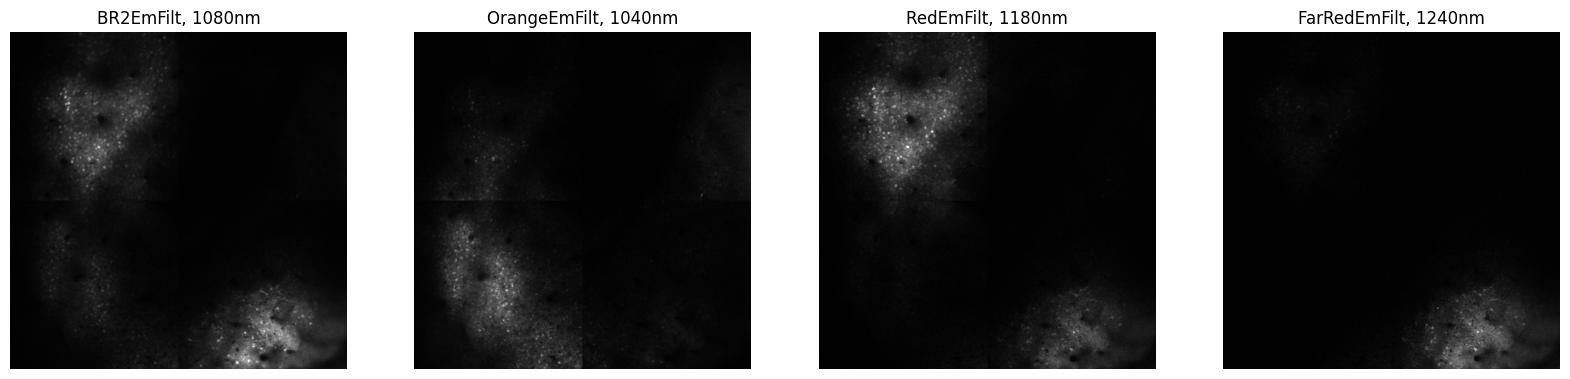

In [3]:
img_size = 824.0
shift = 600.0
vmax = 7000
plane = 40
fig, axs = plt.subplots(1, 4, figsize=(20, 20))
image_sets = [[i1BR, i2BR, i3BR, i4BR], [i1Or, i2Or, i3Or, i4Or], [i1R, i2R, i3R, i4R], [i1FR, i2FR, i3FR, i4FR]]
labels = ['BR2EmFilt, 1080nm', 'OrangeEmFilt, 1040nm', 'RedEmFilt, 1180nm', 'FarRedEmFilt, 1240nm']
stitched_images = []
for i in range(len(image_sets)):
    img = stitch_images(image_sets[i], (img_size-shift)/img_size)
    axs[i].imshow(img[plane, :, :], vmin=0, vmax=vmax, cmap='grey')
    axs[i].axis('off')
    axs[i].set_title(labels[i])
    stitched_images.append(img)

In [5]:
stitched_images[0].shape

(51, 884, 884)

In [9]:
path1 = "/Volumes/2P3_data/Sam/unmixing_coefficients/spatial control mouse #1 20250722/stitched-images/BR2EmFilt_1080nm_230poc_600pmt/BR2EmFilt_1080nm_230poc_600pmt.ome.tif"
path2 = "/Volumes/2P3_data/Sam/unmixing_coefficients/spatial control mouse #1 20250722/stitched-images/OrangeEmFilt_1040nm_298poc_700pmt/OrangeEmFilt_1040nm_298poc_700pmt.ome.tif"
path3 = "/Volumes/2P3_data/Sam/unmixing_coefficients/spatial control mouse #1 20250722/stitched-images/RedEmFilt_1180nm_348poc_700pmt/RedEmFilt_1180nm_348poc_700pmt.ome.tif"
path4 = "/Volumes/2P3_data/Sam/unmixing_coefficients/spatial control mouse #1 20250722/stitched-images/FarRedEmFilt_1240nm_493poc_700pmt/FarRedEmFilt_1240nm_493poc_700pmt.ome.tif"

paths = [path1, path2, path3, path4]

In [11]:
for i in range(len(paths)):
    tf.imwrite(paths[i], stitched_images[i])

In [ ]:
# playing around with pipeline for combining static and functional ROIs

def labels_to_stat(labels, Lx, Ly):
    """
    Convert an integer-labeled ROI image into a list of Suite2p-style `stat` dicts.
    labels: 2D array (Ly x Lx) with 0=background, 1..N = ROI ids
    """
    assert labels.shape == (Ly, Lx)
    stats = []
    max_label = int(labels.max())
    for roi_id in range(1, max_label + 1):
        ys, xs = np.where(labels == roi_id)
        if ys.size == 0:
            continue
        ipix = ys.astype(np.int64) * Lx + xs.astype(np.int64)
        med = np.array([np.median(xs), np.median(ys)], dtype=np.float32)
        lam = np.ones(ys.size, dtype=np.float32)  # weights; uniform is fine for viewing
        npix = int(ys.size)
        radius = float(np.sqrt(npix / np.pi))     # a rough radius for display

        s = {
            'xpix': xs.astype(np.int32),
            'ypix': ys.astype(np.int32),
            'ipix': ipix.astype(np.int64),
            'lam': lam,
            'med': med,
            'npix': npix,
            'radius': radius,
            # optional fields the GUI tolerates being absent; include a few useful ones:
            'overlap': False,
        }
        stats.append(s)
    return stats


# 